In [125]:
import argparse
import json
import logging
import csv

import os
import sys
sys.path.append("../..")
from pathlib import Path
from tqdm import tqdm

from monai.networks.nets import DiffusionModelUNet
import torch
from monai.config import print_config
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import monai.transforms as transforms

import utils.custom_transforms as custom_transforms
import utils.simplex_ddpm as simplex_ddpm

import AnoDDPM.simplex as simplex
from skimage import exposure
from scipy.ndimage import gaussian_filter, median_filter, percentile_filter, grey_dilation, grey_closing, maximum_filter, grey_opening

import numpy as np
import matplotlib.pyplot as plt
import copy

from scipy import stats

import lpips

In [2]:
DEVICE_TYPE = "cuda:1"
device = torch.device(DEVICE_TYPE)

set_determinism(0)

ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:

IMAGE_SIZE = 128

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)

In [165]:

batch_size = 10
num_workers = 8


# transforms
test_transforms_adc = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=1000.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=3000.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
        #transforms.EnsureType(device=device, track_meta=False)
    ]
)

test_transforms_flair = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=450.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
        #transforms.EnsureType(device=device, track_meta=False)
    ]
)


#### ISLES ADC lesion images

In [ ]:
large_group = ['sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0230_ses-0001_msk.nii.gz', 'sub-strokecase0237_ses-0001_msk.nii.gz', 'sub-strokecase0240_ses-0001_msk.nii.gz', 'sub-strokecase0246_ses-0001_msk.nii.gz']
large_group_images_adc = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in large_group]
large_group_images_flair = [ROOT_DIR+"datasets/final_flair_dataset_small/isles_registered/"+filename.replace("msk", "FLAIR") for filename in large_group]



test_anomaly_large_ds_adc = CacheDataset(data=large_group_images, transform=test_transforms_adc)
test_anomaly_large_ds_flair = CacheDataset(data=large_group_images_flair, transform=test_transforms_flair)

test_anomaly_large_loader_adc = DataLoader(
        test_anomaly_large_ds_adc, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

test_anomaly_large_loader_flair = DataLoader(
        test_anomaly_large_ds_flair, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:07<00:00,  5.45it/s]


In [183]:
large_group_masks = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_masks_registered/"+filename for filename in large_group]

test_masks_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2, offset=+2),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
        custom_transforms.SetBackgroundToZero()
    ]
)

test_masks_large_ds = CacheDataset(data=large_group_masks, transform=test_masks_transforms)

test_masks_large_loader = DataLoader(
    test_masks_large_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 15.08it/s]


In [167]:
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 64, 64),
    attention_levels=(False, False, True, True),
    num_head_channels=8
)
model.to(device)

model_path = ROOT_DIR+"AnoDiffExperiments/experiment_0/exp_0_2/models/exp_0_2_best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=DEVICE_TYPE))

model.eval()



DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 32, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler): Diffus

In [168]:
infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(num_train_timesteps=1000, schedule="cosine")

### Thor specifics

In [169]:
l_pips_sq = lpips.LPIPS(pretrained=True, pnet_rand=False, net='squeeze', eval_mode=True, spatial=True, lpips=True).to(device)

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [on]
Loading model from: /home/fehrdelt/.local/lib/python3.10/site-packages/lpips/weights/v0.1/squeeze.pth


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.


In [170]:
def lpips_loss(anomaly_img, ph_img, retPerLayer=False):
    """
    :param anomaly_img: anomaly image
    :param ph_img: pseudo-healthy image
    :param retPerLayer: whether to return the loss per layer
    :return: LPIPS loss
    """
    if len(ph_img.shape) == 2:
        ph_img = torch.unsqueeze(torch.unsqueeze(ph_img, 0), 0)
        anomaly_img = torch.unsqueeze(torch.unsqueeze(anomaly_img, 0), 0)
    

    anomaly_img = ((anomaly_img * 2) - 1).repeat(1,3,1,1)
    ph_img = ((ph_img * 2) - 1).repeat(1,3,1,1)

    loss_lpips = l_pips_sq(anomaly_img, ph_img, normalize=True, retPerLayer=retPerLayer)
    if retPerLayer:
        loss_lpips = loss_lpips[1][0]
    return loss_lpips.cpu().detach().numpy()

In [171]:
def get_saliency( x, x_rec, retPerLayer=False):
    saliency = lpips_loss(x, x_rec, retPerLayer)
    saliency = gaussian_filter(saliency, sigma=2)
    return saliency

In [172]:
def compute_residual(x, x_rec, hist_eq=False):
    """
    :param x_rec: reconstructed image
    :param x: original image
    :param hist_eq: whether to perform histogram equalization
    :return: residual image
    """
    if hist_eq:
        x_rescale = exposure.equalize_adapthist(x.cpu().detach().numpy())
        x_rec_rescale = exposure.equalize_adapthist(x_rec.cpu().detach().numpy())
        x_res = np.abs(x_rec_rescale - x_rescale)
    else:
        x_res = np.abs(x_rec.cpu().detach().numpy() - x.cpu().detach().numpy())

    return x_res

In [173]:
def get_anomaly_mask(x, x_rec, hist_eq=False, retPerLayer=False):

    x_res = compute_residual(x, x_rec, hist_eq=hist_eq)

    lpips_mask = get_saliency(x, x_rec, retPerLayer=retPerLayer).clip(0,1) 

    x_res2 = np.asarray([(x_res[i] / (np.percentile(x_res[i], 95) + 1e-8)) for i in range(x_res.shape[0])]).clip(0, 1)

    combined_mask_np = lpips_mask * x_res #+ x_res) / 2
    combined_mask_np2 = (lpips_mask * x_res) # x_res2
    # # anomalous: high value, healthy: low value

    # combined_mask_np = area_opening((combined_mask_np * 255).astype(np.uint8)) / 255.0#, square(7))
    # combined_mask_np = closing((combined_mask_np * 255).astype(np.uint8), footprint=np.ones(9,9)) / 255.0#, square(7))
    # # combined_mask_np = ndimage.grey_dilation((combined_mask_np * 255).astype(np.uint8), size=(3)) / 255.0#, square(7))
    
    combined_mask = torch.Tensor(combined_mask_np).to(device)
    # combined_mask = dilate_masks(combined_mask)
    
    combined_mask2 = torch.Tensor(combined_mask_np2).to(device)

    combined_mask = (combined_mask / (torch.max(combined_mask) + 1e-8)).clip(0,1)
    # x_res_neg = (x-x_rec)
    return combined_mask, combined_mask2, torch.Tensor(x_res).to(device)
    # return torch.Tensor(x_res).to(device), torch.Tensor(x_res).to(device), torch.Tensor(x_res).to(device)

In [174]:
def get_region_anomaly_mask(ano_map, kernel_size=13):
    # input_image_ = (np.squeeze(copy.deepcopy(input_image).cpu().detach().numpy())*255).astype(np.uint8)
    final_anomaly_map = (grey_closing(ano_map, size=(1,1,kernel_size,kernel_size), mode='nearest'))#+ ano_map)/2
    final_anomaly_map = (grey_dilation(final_anomaly_map, size=(1,1,kernel_size,kernel_size), mode='nearest') + ano_map)/2
    final_anomaly_map = final_anomaly_map.clip(0,1)
    # final_anomaly_map = ((2**final_anomaly_map)-1).clip(0,1)
    return final_anomaly_map

In [175]:
timesteps_harmonization = [200, 160, 120, 80, 40, 10]

In [176]:
@torch.no_grad()
def my_sample(image, infer_scheduler, timesteps, return_intermediates=False):
    
    simplexObj = simplex.Simplex_CLASS()

    noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape, normalize=False).to(device)


    if timesteps >= infer_scheduler.num_train_timesteps:
        print(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)


    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()


    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO


    intermediates = []
    intermediates_step = 20

            
    for t in tqdm(range(timesteps, 0, -1)): # va de timesteps à 0
        
        model_output = model(image, timesteps=torch.Tensor((t,)).to(device), context=None)
        
        image, _ = infer_scheduler.step(model_output, t, image)
    
        if (t== timesteps-1 or t%intermediates_step == 0) and return_intermediates:
            intermediates.append(image)

    if return_intermediates:
        return image, intermediates
    else:
        return image

In [177]:
@torch.no_grad()
def sample_thor(image, infer_scheduler, timesteps=100, return_intermediates=False):
    
    if timesteps >= infer_scheduler.num_train_timesteps:
        print(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)
    
    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    simplexObj = simplex.Simplex_CLASS()

    original_image = copy.deepcopy(image)

    noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape).to(device)

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO
    

    intermediates_mixed_images_visualize = []
    intermediates_pseudo_anomaly_masks = []
    intermediates_pseudo_anomaly_masks_processed = []

            
    for t in tqdm(range(timesteps, 0, -1)): # goes from timesteps to 0
        
        # compute previous image
        model_output = model(image, timesteps=torch.Tensor((t,)).to(device), context=None)
        image, image_before_step = infer_scheduler.step(model_output, t, image) # here image_before_step is just the image at the timestep+1
            
        
        if t in timesteps_harmonization:
            
            
            pseudo_anomaly_mask, _, _ = get_anomaly_mask(copy.deepcopy(image_before_step), copy.deepcopy(original_image), hist_eq=False)
            
            intermediates_pseudo_anomaly_masks.append(pseudo_anomaly_mask)
            pseudo_anomaly_mask = pseudo_anomaly_mask.cpu().detach().numpy()
            

            pseudo_anomaly_mask_processed = torch.Tensor(get_region_anomaly_mask(pseudo_anomaly_mask, kernel_size=6)).to(device).clip(0,1) # simple erosion dilation 
            

            pseudo_anomaly_mask_processed = pseudo_anomaly_mask_processed.clip(0,1) 

            intermediates_pseudo_anomaly_masks_processed.append(pseudo_anomaly_mask_processed)

            image_0 = pseudo_anomaly_mask_processed * image_before_step + (1-pseudo_anomaly_mask_processed) * original_image
            
            image_0 = torch.clamp(image_0, 0, 1)
            
            
            image = infer_scheduler.add_noise(image_0, noise, torch.Tensor((t,)).to(device).long())
            
            intermediates_mixed_images_visualize.append(image)

    if return_intermediates:
        return image, intermediates_mixed_images_visualize, intermediates_pseudo_anomaly_masks, intermediates_pseudo_anomaly_masks_processed
    else:
        return image, intermediates_pseudo_anomaly_masks

**play with get_region_anomaly_mask() parameters** \
**Verif lpips_loss**

In [184]:
mask_ground_truth_batch = next(iter(test_masks_large_loader))
mask_ground_truth_batch = mask_ground_truth_batch.to(device)

batch = next(iter(test_anomaly_large_loader_flair))
batch = batch.to(device)

image, intermediates_mixed_images_visualize, intermediates_pseudo_anomaly_masks, intermediates_pseudo_anomaly_masks_processed = sample_thor(batch, infer_scheduler, timesteps=250, return_intermediates=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:28<00:00,  8.81it/s]


In [179]:
harmonic_mean = stats.hmean(np.stack([p.cpu() for p in intermediates_pseudo_anomaly_masks_processed]), axis=0)

In [180]:
image_sample_no_thor, intermediates_no_thor = my_sample(batch, infer_scheduler, timesteps=250, return_intermediates=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:27<00:00,  8.99it/s]


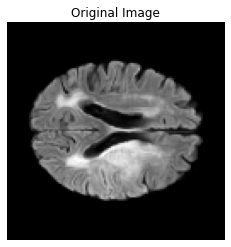

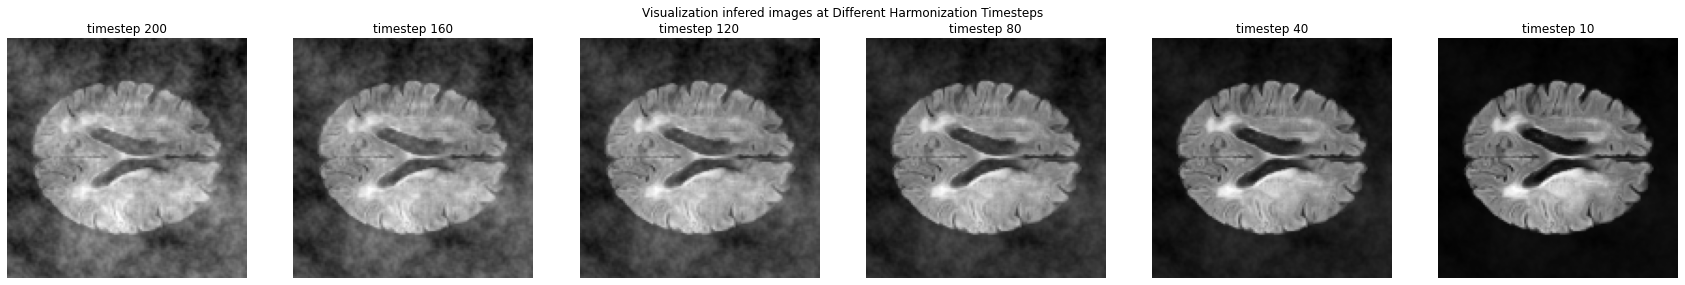

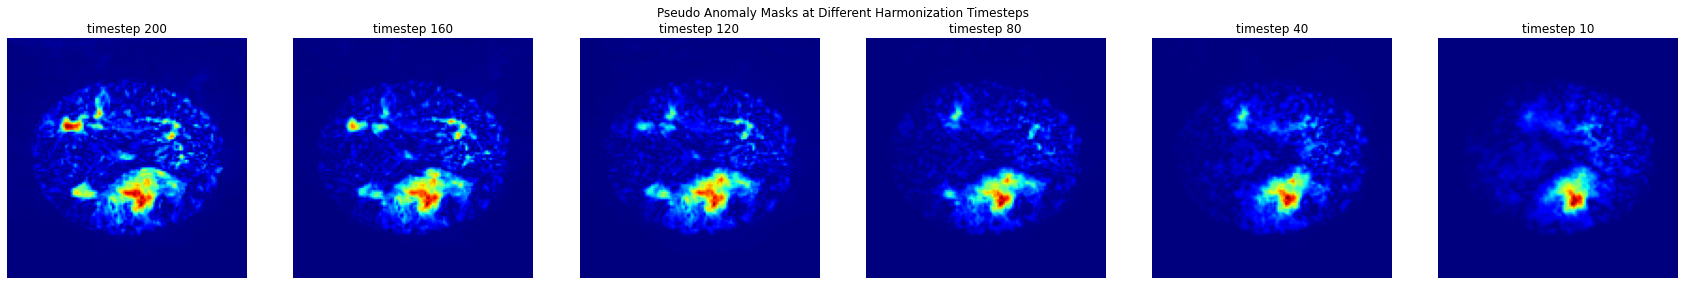

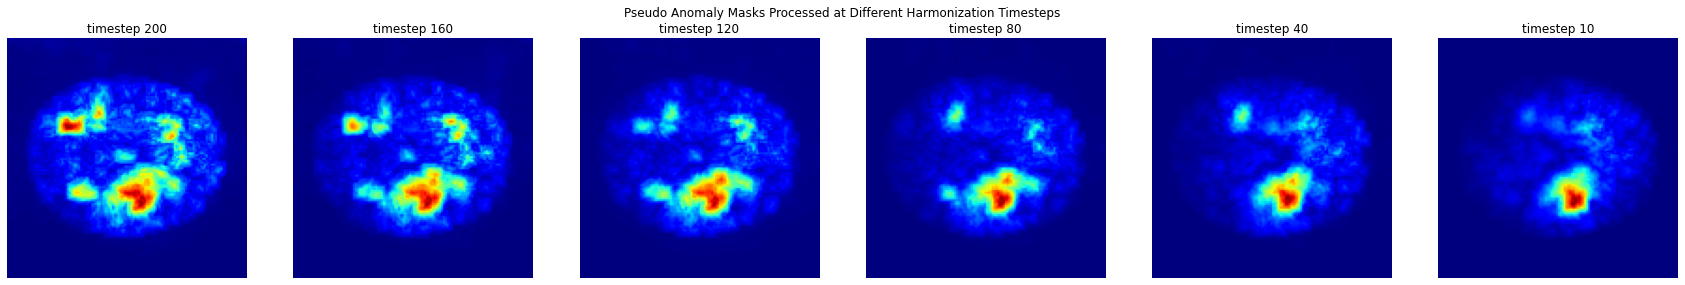

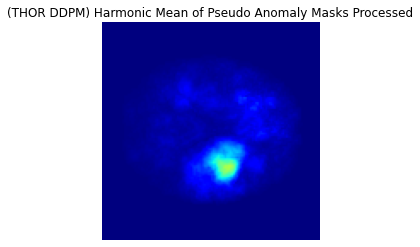

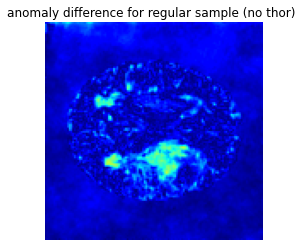

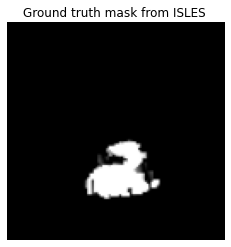

In [ ]:
# ----------------------------------------------------------------------------
# Plot the original image (batch index 1)
plt.figure(figsize=(4,4))
plt.imshow(batch[1].cpu().detach().numpy().squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


# ----------------------------------------------------------------------------
# Plot the first image (batch index 1) from each visualize image side by side
visu = intermediates_mixed_images_visualize
n = len(visu)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
plt.suptitle("Visualization infered images at Different Harmonization Timesteps")
if n == 1:
    axes = [axes]

for i, v in enumerate(visu):
    img = v[1].detach().float().cpu().numpy().squeeze()  # (H, W)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"timestep {timesteps_harmonization[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------
# Plot the first image (batch index 1) from each pseudo anomaly mask side by side
masks = intermediates_pseudo_anomaly_masks
n = len(masks)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
plt.suptitle("Pseudo Anomaly Masks at Different Harmonization Timesteps")
if n == 1:
    axes = [axes]

for i, m in enumerate(masks):
    img = m[1].detach().float().cpu().numpy().squeeze()  # (H, W)
    axes[i].imshow(img, cmap='jet')
    axes[i].set_title(f"timestep {timesteps_harmonization[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------
# Plot the first image (batch index 1) from each pseudo anomaly mask side by side
masks = intermediates_pseudo_anomaly_masks_processed
n = len(masks)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
plt.suptitle("Pseudo Anomaly Masks Processed at Different Harmonization Timesteps")
if n == 1:
    axes = [axes]

for i, m in enumerate(masks):
    img = m[1].detach().float().cpu().numpy().squeeze()  # (H, W)
    axes[i].imshow(img, cmap='jet')
    axes[i].set_title(f"timestep {timesteps_harmonization[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------
# Plot the harmonic mean of intermediates_pseudo_anomaly_masks_processed (batch index 1)
plt.figure(figsize=(4,4))
plt.imshow(harmonic_mean[1].squeeze(), cmap='jet', vmin=0.0, vmax=0.7)
plt.title("(THOR DDPM) Harmonic Mean of Pseudo Anomaly Masks Processed")
plt.axis('off')
plt.show()


# ----------------------------------------------------------------------------
# Plot the anomaly difference for regular sample (no thor) (batch index 1)
plt.figure(figsize=(4,4))
plt.imshow(np.abs(image_sample_no_thor[1].cpu().detach().numpy().squeeze()-batch[1].cpu().detach().numpy().squeeze()), cmap='jet', vmin=0.0, vmax=0.7)
plt.title("anomaly difference for regular sample (no thor) ")
plt.axis('off')
plt.show()


# ----------------------------------------------------------------------------
# Plot the ground truth mask isles (batch index 1)
plt.figure(figsize=(4,4))
plt.imshow(mask_ground_truth_batch[1].cpu().detach().numpy().squeeze(), cmap='gray')
plt.title("Ground truth mask from ISLES ")
plt.axis('off')
plt.show()